# L5. Teaching It to See

The device learns a new object by writing example vectors to memory, no retraining and no fine-tuning. Show it something new, and seconds later it recognizes that object from a different angle. Then everything you built lands in one assistant that answers questions and recognizes what you taught it — offline.

## 1. An object-memory shard

In [1]:
from qdrant_edge import (
    EdgeShard, EdgeConfig, EdgeVectorParams, Distance,
    Point, UpdateOperation, Query, QueryRequest,
)
from helper import embed_image, fresh_start

OBJECT_DIR = fresh_start("./object_shard")

config = EdgeConfig(
    vectors={
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
object_shard = EdgeShard.create(OBJECT_DIR, config)
RECOGNIZE_THRESHOLD = 0.80
print("Object shard ready. threshold =", RECOGNIZE_THRESHOLD)

Object shard ready. threshold = 0.8


## 2. The objects on hand

Object photos: Wikimedia Commons, CC BY-SA — full attribution in `../data/objects/CREDITS.json`.

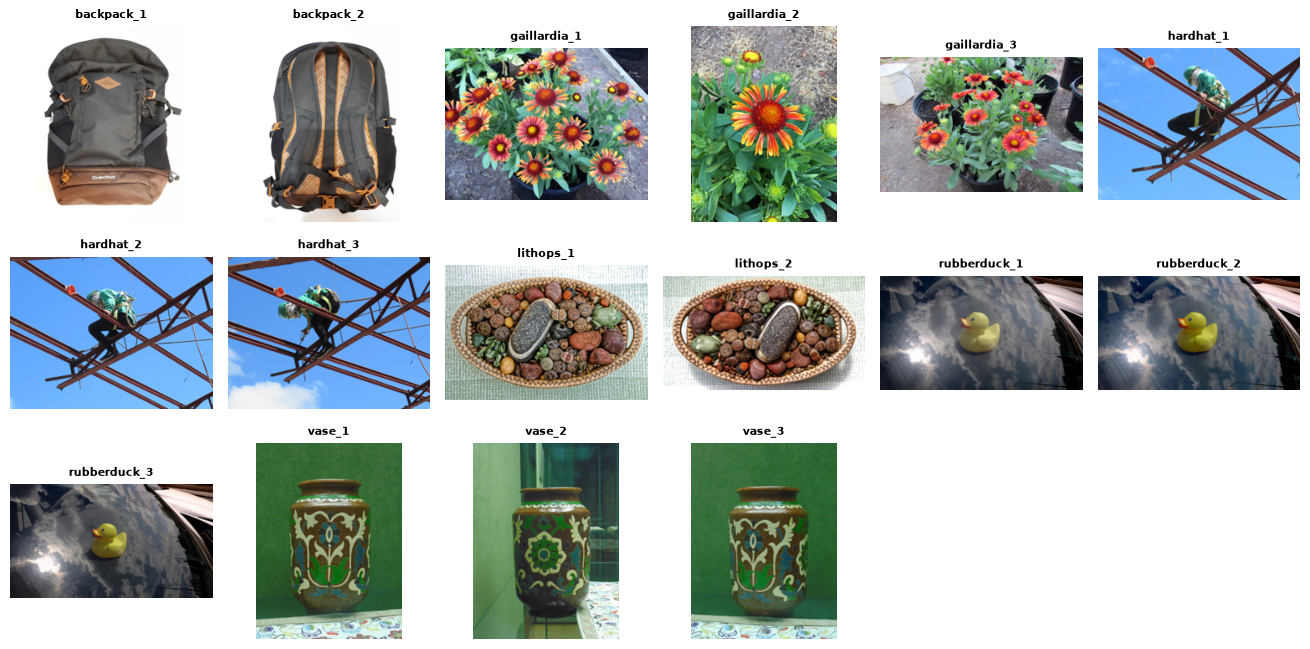

In [2]:
from pathlib import Path
from helper import show_images

views = sorted(Path("../data/objects").glob("*.jpg"))
show_images(views, captions=[p.stem for p in views])

## 3. Teach what it already knows

In [3]:
def teach(shard, object_id, label, view_paths, start_id, note=None):
    vectors = embed_image(view_paths)
    points = [
        Point(
            id=start_id + i,
            vector={"image": vectors[i]},
            payload={"object_id": object_id, "label": label, "view_id": i,
                     "file": view_paths[i],
                     **({"note": note} if note else {})},
        )
        for i in range(len(view_paths))
    ]
    shard.update(UpdateOperation.upsert_points(points))
    shard.optimize()


teach(object_shard, "lithops", "lithops (living stone)",
      ["../data/objects/lithops_1.jpg",
       "../data/objects/lithops_2.jpg"], start_id=0)
teach(object_shard, "backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=100,
      note="Quechua daypack, bought at SportsWorld, $45")
print("Known: lithops (2 views), backpack (1 view).",
      object_shard.info().points_count, "views stored")

Known: lithops (2 views), backpack (1 view). 3 views stored


## 4. Show it something new — not recognized yet

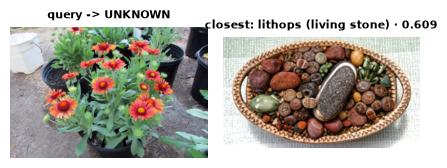

In [4]:
def recognize(shard, query_path, limit=1):
    query_vector = embed_image([query_path])[0]
    hits = shard.query(
        QueryRequest(
            query=Query.Nearest(query_vector, using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    top = hits[0]
    return top, top.score >= RECOGNIZE_THRESHOLD, hits


query = "../data/objects/gaillardia_3.jpg"
top, known, _ = recognize(object_shard, query)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([query, top.payload["file"]],
            captions=[f"query -> {verdict}",
                      f"closest: {top.payload['label']} · {top.score:.3f}"])

## 5. Teach it the new object

In [5]:
# Give the new object a label, then teach two views.
my_label = "orange flower"
teach(object_shard, "flower_01", my_label,
      ["../data/objects/gaillardia_1.jpg",
       "../data/objects/gaillardia_2.jpg"], start_id=10)
print(f'Taught "{my_label}". Shard now holds',
      object_shard.info().points_count, "views")

Taught "orange flower". Shard now holds 5 views


## 6. The payoff: recognize it from a new angle

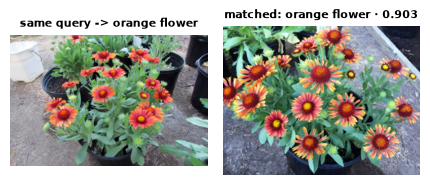

In [6]:
top, known, _ = recognize(object_shard, query)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([query, top.payload["file"]],
            captions=[f"same query -> {verdict}",
                      f"matched: {top.payload['label']} · {top.score:.3f}"])

## 7. Inspect the threshold gap

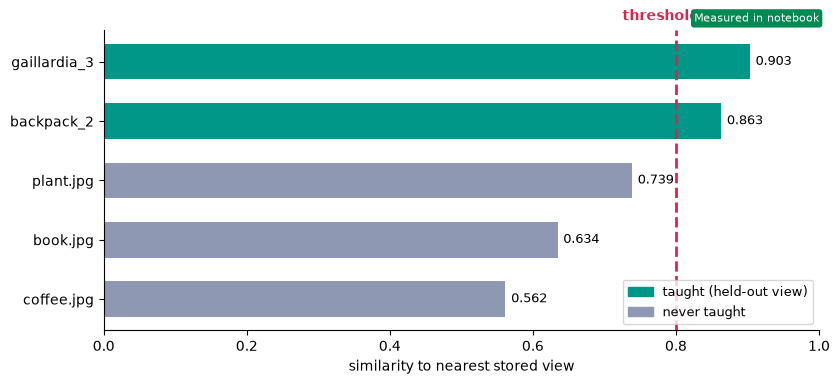

In [7]:
from helper import score_gap_chart

taught = []
for path in ["../data/objects/gaillardia_3.jpg",
             "../data/objects/backpack_2.jpg"]:
    t, _, _ = recognize(object_shard, path)
    taught.append((Path(path).stem, t.score))

foreign = []
for name in ["plant.jpg", "book.jpg", "coffee.jpg"]:
    t, _, _ = recognize(object_shard, f"../data/images/{name}")
    foreign.append((name, t.score))

score_gap_chart(taught, foreign, RECOGNIZE_THRESHOLD)

## 8. Your turn: teach an object yourself

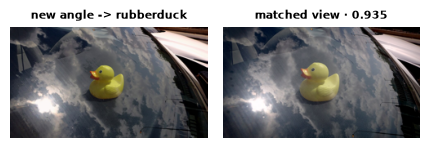

In [8]:
# Pick a 3-view object from the gallery: rubberduck, vase, hardhat.
# Change this and re-run.
my_object = "rubberduck"

teach(object_shard, my_object, my_object,
      [f"../data/objects/{my_object}_1.jpg",
       f"../data/objects/{my_object}_2.jpg"], start_id=300)

held_out = f"../data/objects/{my_object}_3.jpg"
top, known, _ = recognize(object_shard, held_out)
verdict = top.payload["label"] if known else "UNKNOWN"
show_images([held_out, top.payload["file"]],
            captions=[f"new angle -> {verdict}",
                      f"matched view · {top.score:.3f}"])

## 9. Assemble the assistant

In [9]:
import json
from helper import embed_text

ASSISTANT_DIR = fresh_start("./assistant_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
assistant_shard = EdgeShard.create(ASSISTANT_DIR, config)

day = json.load(open("../data/memories.json"))
history = json.load(open("../data/recent_days.json"))
notes = [m for m in day + history if m["source_type"] in ("text", "voice")]
photos = [m for m in day if m["source_type"] == "photo"]

text_vectors = embed_text([m.get("note") or m["transcript"] for m in notes])
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"text": text_vectors[i]}, payload=m)
    for i, m in enumerate(notes)
]))
image_vectors = embed_image([f"../data/images/{m['file']}" for m in photos])
assistant_shard.update(UpdateOperation.upsert_points([
    Point(id=m["id"], vector={"image": image_vectors[i]}, payload=m)
    for i, m in enumerate(photos)
]))

teach(assistant_shard, "backpack", "backpack",
      ["../data/objects/backpack_1.jpg"], start_id=5000,
      note="Quechua daypack, bought at SportsWorld, $45")

print(assistant_shard.info().points_count,
      "memories: a day of captures, weeks of notes, one taught object")

145 memories: a day of captures, weeks of notes, one taught object


## 10. The payoff: ask it about your day


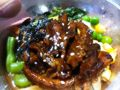

In [10]:
from helper import embed_query, embed_query_clip, memory_inbox


def recall(shard, question, limit=3):
    text_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query(question), using="text"),
            limit=limit,
            with_payload=True,
        )
    )
    image_hits = shard.query(
        QueryRequest(
            query=Query.Nearest(embed_query_clip(question), using="image"),
            limit=limit,
            with_payload=True,
        )
    )
    return {
        "Photos": [h for h in image_hits
                   if h.payload.get("source_type") == "photo"][:1],
        "Voice Notes": [h for h in text_hits
                        if h.payload.get("source_type") == "voice"],
        "Text Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "text"],
    }


hits = recall(assistant_shard, "the ramen place downtown")
memory_inbox(hits, "../data/images")

## 11. The payoff: show it what you taught

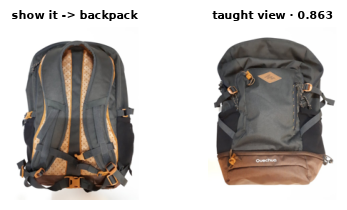

I remember this: Quechua daypack, bought at SportsWorld, $45


In [11]:
top, known, _ = recognize(assistant_shard, "../data/objects/backpack_2.jpg")
verdict = top.payload["label"] if known else "UNKNOWN"
show_images(["../data/objects/backpack_2.jpg", top.payload["file"]],
            captions=[f"show it -> {verdict}",
                      f"taught view · {top.score:.3f}"])
if known:
    print("I remember this:", top.payload["note"])

## 12. The payoff: it all persists, offline

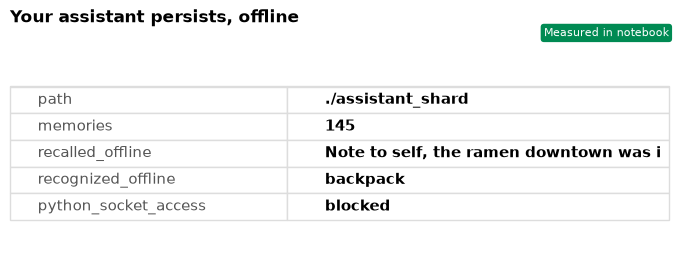

In [12]:
from helper import no_network, receipt_table

before = assistant_shard.info().points_count
assistant_shard.close()
with no_network():
    assistant_shard = EdgeShard.load(ASSISTANT_DIR)
    hits = recall(assistant_shard, "the ramen place downtown")
    top, known, _ = recognize(assistant_shard,
                              "../data/objects/backpack_2.jpg")

receipt_table([
    ("path", ASSISTANT_DIR),
    ("memories", before),
    ("recalled_offline", hits["Voice Notes"][0].payload["transcript"][:38]),
    ("recognized_offline", top.payload["label"] if known else "UNKNOWN"),
    ("python_socket_access", "blocked"),
], title="Your assistant persists, offline")